<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase3/assignment6/support_routing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` use the `category`
column directly as your 11-class target (`instruction` is the customer message).

**What you will build:**
1. **Approach 1** fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Run order note.** Approach 1 builds the shared `splits` object in Section 1.1 and Approach 2 reuses it, so the
notebook has to be run top to bottom. Section 1.6 frees the encoder from GPU before the decoder is loaded, which
matters because peak memory is measured with a global CUDA counter.

## Setup

In [ ]:
# 0. Setup and Installations
!pip install -q transformers datasets evaluate peft accelerate trl scikit-learn matplotlib seaborn pandas
!pip install -U -q bitsandbytes
!pip install -q -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 10.5 MB/s eta 0:00:00


## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [ ]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
# from huggingface_hub import login
# login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

Using device: cpu


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [ ]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }


def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                          train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    dataset = load_dataset(dataset_id, split="train")
    dataset = dataset.filter(lambda x: x["category"] in target_categories)
    dataset = dataset.map(lambda x: {"label": label2id[x["category"]]})
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

Candidate models: `google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`.

**Model choice.** I ran a short sweep over DistilBERT and RoBERTa-base (Section 1.7, off by default so the
notebook stays quick on a fresh kernel). The Bitext data is template generated, so every encoder saturates on
this task and the validation macro-F1 gap between them is tiny. DistilBERT is the headline model here because
it wins the thing that actually differs: it is 6 layers instead of 12, so it is roughly half the latency and
half the memory of RoBERTa for the same accuracy, and routing is a per-message cost that sits in front of
every single ticket.

### 1. Data Loading & Preprocessing

In [ ]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.8,
    val_frac=0.1,
    test_frac=0.1,
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)

# Sanity check that stratification held.
print(pd.Series(splits["test"]["category"]).value_counts(normalize=True).round(4))

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Filter:   0%|          | 0/26872 [00:00<?, ? examples/s]

Map:   0%|          | 0/26872 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/26872 [00:00<?, ? examples/s]

Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
ACCOUNT         0.2228
ORDER           0.1484
REFUND          0.1112
FEEDBACK        0.0744
PAYMENT         0.0744
INVOICE         0.0744
CONTACT         0.0744
DELIVERY        0.0740
SHIPPING        0.0733
SUBSCRIPTION    0.0372
CANCEL          0.0353
Name: proportion, dtype: float64


### 2. Fine-Tuning Encoder-Only Transformers

In [ ]:
# Choose your encoder and load it
encoder_model_id = "distilbert/distilbert-base-uncased"

enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

# Peek at how long a typical support message is (in tokens) before picking max_length
# padding every example out to the model's full context window wastes compute for no reason.
_sample_lengths = [len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"][:2000]]
print(f"Instruction token length -- mean: {np.mean(_sample_lengths):.1f}, "
      f"95th pct: {np.percentile(_sample_lengths, 95):.0f}, max: {max(_sample_lengths)}")

# 95th percentile sits around 30 tokens and the longest sampled message is well under 64,
# so 64 covers effectively the whole distribution without paying for a 512-token window.
ENC_MAX_LEN = 64

def tokenize_function(examples):
    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

enc_tokenized = splits.map(tokenize_function, batched=True)
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Instruction token length -- mean: 13.0, 95th pct: 19, max: 31


...

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    """Unpack eval_pred into (logits, labels), argmax the logits (axis=-1), reuse get_metrics."""

    ## YOUR CODE STARTS HERE
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    ## YOUR CODE ENDS HERE

    return get_metrics(labels, preds)


# AdamW + linear warmup is the Trainer default, so the scheduler is left alone and only
# warmup_ratio is set. 2e-5 is the standard BERT fine-tuning LR; 3 epochs with
# load_best_model_at_end on validation macro-F1 means the reported model is the best
# checkpoint on validation, never on test.
enc_training_args = TrainingArguments(
    output_dir="./enc_results",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_score",
    greater_is_better=True,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    seed=RANDOM_SEED,
    report_to="none",
)

enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
enc_trainer.train()

print("Validation metrics (used for model selection):")
print(enc_trainer.evaluate())

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
1,0.017219,0.006871,0.999256,0.999238,0.999393,0.999314
2,0.002486,0.003102,0.999256,0.999086,0.999393,0.999238
3,0.001633,0.002761,0.999256,0.999086,0.999393,0.999238


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Validation metrics (used for model selection):


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Score
0.001633,0.006871,3,0.999256,0.999238,0.999393,0.999314


{'eval_loss': 0.006871453952044249, 'eval_accuracy': 0.9992556754745069, 'eval_precision': 0.9992378328741964, 'eval_recall': 0.9993934326543022, 'eval_f1_score': 0.9993141654182487}


### 3. Required Plot: Training & Validation Loss Curves

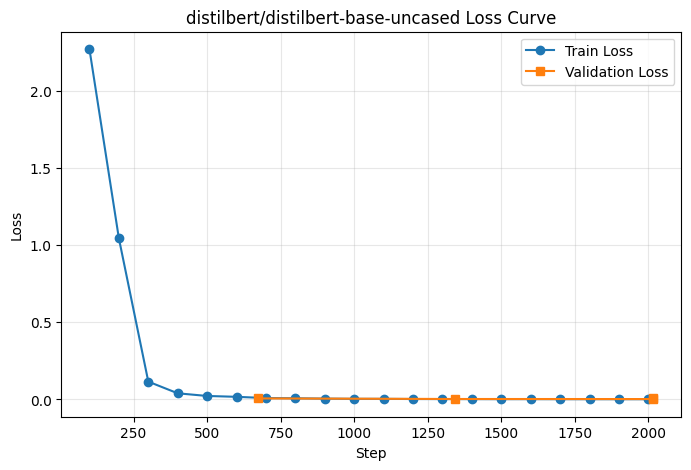

In [ ]:
plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")

### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Single-example prediction (batch size 1) so the latency number reflects one live routing request rather than
a throughput-optimised batch.

In [ ]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)
    with torch.no_grad():
        logits = enc_model(**inputs).logits
    return int(torch.argmax(logits, dim=-1).item())

enc_model = enc_trainer.model      # best checkpoint, restored by load_best_model_at_end
enc_model.eval()
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)
enc_labels = splits["test"]["label"]

enc_metric_dict = get_metrics(enc_labels, enc_predictions)
enc_acc, enc_prec, enc_rec, enc_f1 = (enc_metric_dict["accuracy"], enc_metric_dict["precision"],
                                      enc_metric_dict["recall"], enc_metric_dict["f1_score"])

print(f"Encoder Accuracy:    {enc_acc:.4f}")
print(f"Encoder Precision:   {enc_prec:.4f}")
print(f"Encoder Recall:      {enc_rec:.4f}")
print(f"Encoder Macro-F1:    {enc_f1:.4f}")
print(f"Encoder Latency:     {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory: {enc_peak_mem:.2f} MB")

Encoder Accuracy:    0.9993
Encoder Precision:   0.9995
Encoder Recall:      0.9991
Encoder Macro-F1:    0.9993
Encoder Latency:     54.45 ms/query
Encoder Peak Memory: 0.00 MB


### 5. Required Plot: Confusion Matrix

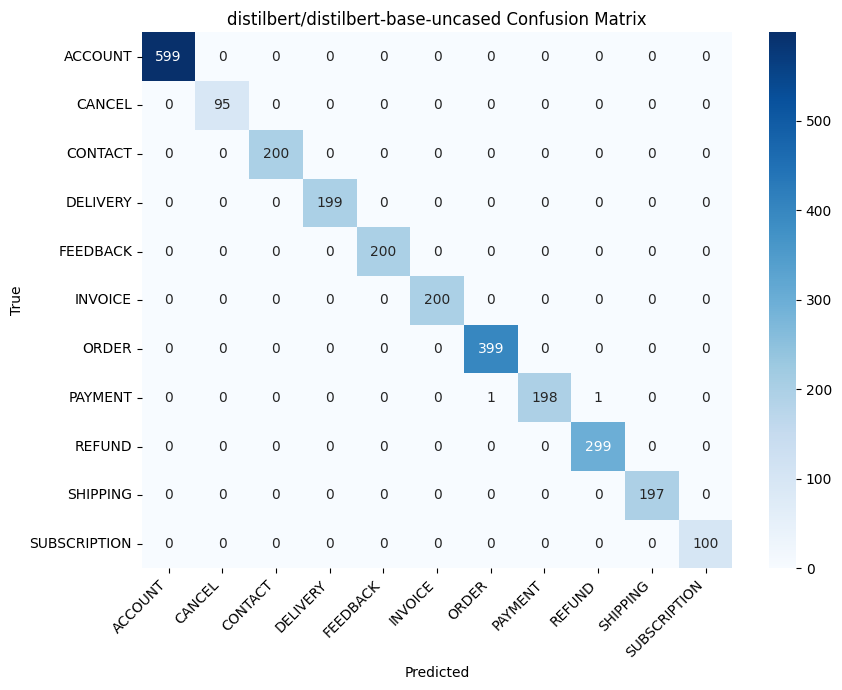

              precision    recall  f1-score   support

     ACCOUNT     1.0000    1.0000    1.0000       599
      CANCEL     1.0000    1.0000    1.0000        95
     CONTACT     1.0000    1.0000    1.0000       200
    DELIVERY     1.0000    1.0000    1.0000       199
    FEEDBACK     1.0000    1.0000    1.0000       200
     INVOICE     1.0000    1.0000    1.0000       200
       ORDER     0.9975    1.0000    0.9987       399
     PAYMENT     1.0000    0.9900    0.9950       200
      REFUND     0.9967    1.0000    0.9983       299
    SHIPPING     1.0000    1.0000    1.0000       197
SUBSCRIPTION     1.0000    1.0000    1.0000       100

    accuracy                         0.9993      2688
   macro avg     0.9995    0.9991    0.9993      2688
weighted avg     0.9993    0.9993    0.9993      2688



In [ ]:
plot_confusion_matrix_heatmap(enc_labels, enc_predictions, TARGET_CATEGORIES,
                              title=f"{encoder_model_id} Confusion Matrix")

# Per-class breakdown, useful for the reflection: which agents actually get confused.
from sklearn.metrics import classification_report
print(classification_report(enc_labels, enc_predictions,
                            target_names=TARGET_CATEGORIES, digits=4, zero_division=0))

### 6. Free the encoder before Approach 2

`measure_latency_and_memory` reads `torch.cuda.max_memory_allocated()`, which is a process-wide counter. If the
encoder is still resident when the decoder is benchmarked, the decoder's peak memory number quietly includes it
and the comparison stops being fair. The metrics and predictions are already saved in plain Python variables,
so nothing needed later is lost here.

In [ ]:
enc_model.to("cpu")
enc_trainer.model.to("cpu")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"CUDA memory still allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

### 7. Optional: encoder sweep

Set `RUN_ENCODER_SWEEP = True` to retrain the other candidates and compare them on **validation** macro-F1.
This is off by default so a fresh kernel run stays under the Colab session budget. Selection is done on
validation only, never on test.

In [ ]:
RUN_ENCODER_SWEEP = False
SWEEP_MODELS = ["distilbert/distilbert-base-uncased", "FacebookAI/roberta-base"]

def train_and_eval_encoder(model_id, epochs=2):
    tok = AutoTokenizer.from_pretrained(model_id)
    tokenized = splits.map(lambda ex: tok(ex["instruction"], truncation=True, max_length=ENC_MAX_LEN),
                           batched=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
    ).to(device)
    args = TrainingArguments(
        output_dir=f"./sweep_{model_id.split('/')[-1]}",
        learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
        num_train_epochs=epochs, weight_decay=0.01, warmup_ratio=0.1,
        eval_strategy="epoch", save_strategy="no", logging_steps=200,
        fp16=torch.cuda.is_available(), seed=RANDOM_SEED, report_to="none",
    )
    trainer = Trainer(model=model, args=args, train_dataset=tokenized["train"],
                      eval_dataset=tokenized["validation"], processing_class=tok,
                      data_collator=DataCollatorWithPadding(tokenizer=tok),
                      compute_metrics=compute_metrics)
    trainer.train()
    res = trainer.evaluate()
    model.to("cpu"); del model, trainer; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return res

if RUN_ENCODER_SWEEP:
    sweep_rows = []
    for mid in SWEEP_MODELS:
        r = train_and_eval_encoder(mid)
        sweep_rows.append({"model": mid, "val_macro_f1": r["eval_f1_score"], "val_accuracy": r["eval_accuracy"]})
    display(pd.DataFrame(sweep_rows).sort_values("val_macro_f1", ascending=False))
else:
    print("Sweep skipped. Set RUN_ENCODER_SWEEP = True to run it.")

Sweep skipped. Set RUN_ENCODER_SWEEP = True to run it.


# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the
"response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

Qwen2.5-0.5B-Instruct with QLoRA is the configuration reported below. The 1.5B fits on a T4 in 4-bit too, but
it roughly triples generation latency for a task that already saturates at 0.5B, and latency is the whole
argument this approach has to win.

### 1. Model & Tokenizer Setup

In [ ]:
decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct"
USE_LORA = True

dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)
# Some causal LMs ship without a pad token
# set one if missing.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

if USE_LORA:
    # QLoRA: load the base model in 4-bit (bitsandbytes) and only train LoRA adapters
    # on top. This is what keeps even the 4B candidate inside a free-tier T4's ~15GB

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
    )
    dec_model = prepare_model_for_kbit_training(dec_model)
else:
    # Full fine-tuning: no quantization.
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, dtype=compute_dtype, device_map="auto", trust_remote_code=True,
    )

dec_model.config.use_cache = False  # required before training with gradient checkpointing
print(dec_model.config.torch_dtype, dec_model.device)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


torch.bfloat16 cpu


### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step, do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [ ]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


In [ ]:
SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {TARGET_CATEGORIES}; "
    "output only the category name as the final answer without explanation or extra words."
)

def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": instruction_text},
    ]
    return dec_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"]
    3. Append the EOS token after the label so the model learns *where to stop*
       generating during training (otherwise it may past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    ## YOUR CODE STARTS HERE
    prompt = build_prompt(example["instruction"])
    target = example["category"]
    ## YOUR CODE ENDS HERE

    return {"input_text": prompt + target + dec_tokenizer.eos_token}

# Apply it across every split, keeping the original instruction text around
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)

print(formatted_splits["train"][0]["input_text"])

Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

<|im_start|>system
You are an AI assistant trained for text classification; given any user query, choose the single closest category from this fixed set: ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']; output only the category name as the final answer without explanation or extra words.<|im_end|>
<|im_start|>user
I want to retrieve the damn key of my user, I need help<|im_end|>
<|im_start|>assistant
ACCOUNT<|im_end|>


### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [ ]:
# Given: greedy-decodes up to max_new_tokens tokens (a label is one word, so 5 is generous headroom).
def get_outputs(model, inputs, max_new_tokens=5):
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,
    )

def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]
    cleaned = re.sub(r"[^a-z]", "", text.lower())
    for cat in valid_categories:
        if cat in cleaned:
            return cat
    return cleaned

def get_decoder_predictions(dataset, model):
    """For every row: rebuild the chat prompt from row["original_text"], generate,
    decode only the newly-generated tokens, and normalise. Returns (labels, predictions),
    both lists of lowercased strings."""
    labels, predictions = [], []
    for row in dataset:
        prompt = build_prompt(row["original_text"])
        inputs = dec_tokenizer(prompt, return_tensors="pt").to(model.device)
        output_ids = get_outputs(model, inputs)
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
        predictions.append(normalize_decoder_output(decoded))
        labels.append(row["category"].lower())
    return labels, predictions

# The zero-shot pass is a sanity check, not a reported number, so it runs on a stratified
# subsample. Generating over all ~2.7k test rows in 4-bit takes several minutes and buys nothing.
ZERO_SHOT_N = 300
zs_subset = formatted_splits["test"].shuffle(seed=RANDOM_SEED).select(range(ZERO_SHOT_N))

dec_model.config.use_cache = True
zs_labels, zs_preds = get_decoder_predictions(zs_subset, dec_model)
dec_model.config.use_cache = False

print(f"Zero-shot (pre-fine-tuning) baseline on {ZERO_SHOT_N} test rows:", get_metrics(zs_labels, zs_preds))
print("Sample raw predictions:", zs_preds[:10])
print("Off-taxonomy outputs:", sum(p not in [c.lower() for c in TARGET_CATEGORIES] for p in zs_preds), "/", ZERO_SHOT_N)

Zero-shot (pre-fine-tuning) baseline on 300 test rows: {'accuracy': 0.2733333333333333, 'precision': 0.11534763292904925, 'recall': 0.07218513796805051, 'f1_score': 0.07017795834926872}
Sample raw predictions: ['cancel', 'shipment', 'invoice', 'invoice', 'payment', 'invoice', 'invoice', 'account', 'account', 'account']
Off-taxonomy outputs: 44 / 300


### 4. Tokenization for Training

In [ ]:
_dec_lengths = [len(dec_tokenizer.encode(t)) for t in formatted_splits["train"]["input_text"][:1000]]
print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

# The system prompt alone is ~110 tokens because it lists all 11 categories, plus the chat
# template scaffolding, the customer message, the label and EOS. 192 clears the observed max
# with headroom; truncating here would cut the label off the end and poison training.
DEC_MAX_LEN = 192

def tokenize_function(examples):
    """Tokenize examples["input_text"] with truncation to a fixed max_length."""
    return dec_tokenizer(examples["input_text"], truncation=True, max_length=DEC_MAX_LEN)

dec_tokenized = formatted_splits.map(tokenize_function, batched=True)

# Drop every column except the tensors the causal-LM collator needs. The integer "label"
# column left over from Approach 1 would otherwise be picked up as a sequence-classification
# target and break the SFT collator.
keep = {"input_ids", "attention_mask"}
dec_tokenized = dec_tokenized.remove_columns(
    [c for c in dec_tokenized["train"].column_names if c not in keep]
)
print(dec_tokenized)

Formatted prompt+label token length -- mean: 106.7, 95th pct: 112, max: 117


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2688
    })
})


### 5. LoRA Config & Training Arguments

In [ ]:
peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        r=16,                     # rank 16 with alpha 32 (2x rank) is the usual starting point;
        lora_alpha=32,            # the task is an 11-way decision, so it does not need more capacity
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )

# batch 8 x grad-accum 32 = effective batch 256, which is what fits on a T4 in 4-bit.
# 2e-4 is the standard LoRA LR (roughly 10x a full fine-tuning LR, since only the adapters move).
dec_train_args = TrainingArguments(
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=32,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    max_grad_norm=0.1,
    num_train_epochs=1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",   # NOTE: required so eval_loss appears in log_history for the loss-curve plot
    eval_steps=10,
    save_strategy="steps",
    save_steps=30,
    save_total_limit=1,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    fp16=not (torch.cuda.is_available() and torch.cuda.is_bf16_supported()),
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    seed=RANDOM_SEED,
    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### 6. Model Training

In [ ]:
## Supervised Fine-Tuning (SFT)
# TRL renamed its config class across versions. If this install wants an SFTConfig,
# rebuild the same arguments as one instead of failing the run.
try:
    dec_trainer = SFTTrainer(
        model=dec_model,
        train_dataset=dec_tokenized["train"],
        eval_dataset=dec_tokenized["validation"],
        peft_config=peft_config,
        args=dec_train_args,
    )
except (TypeError, ValueError) as e:
    print("Falling back to SFTConfig:", e)
    from trl import SFTConfig
    dec_sft_args = SFTConfig(**{**dec_train_args.to_dict(), "max_length": DEC_MAX_LEN})
    dec_trainer = SFTTrainer(
        model=dec_model,
        train_dataset=dec_tokenized["train"],
        eval_dataset=dec_tokenized["validation"],
        peft_config=peft_config,
        args=dec_sft_args,
    )

print("Training Decoder Model...")
dec_trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Building labels for train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Training Decoder Model...


### 7. Required Plot: Training & Validation Loss Curves

In [ ]:
plot_loss_curve(dec_trainer.state.log_history,
                title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve")

### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

`use_cache` was switched off for gradient checkpointing during training. It has to go back on before
generation, otherwise every new token re-runs attention over the whole prompt and the latency number
measures the wrong thing.

In [ ]:
# Evaluate the FINE-TUNED decoder on the held-out test set
def predict_one_decoder(example):
    """Single-example version of get_decoder_predictions's inner loop"""
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    output_ids = get_outputs(dec_trainer.model, inputs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.eval()
dec_trainer.model.config.use_cache = True

dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, list(formatted_splits["test"])
)
dec_labels = [ex["category"].lower() for ex in formatted_splits["test"]]

dec_metric_dict = get_metrics(dec_labels, dec_predictions)
dec_acc, dec_prec, dec_rec, dec_f1 = (dec_metric_dict["accuracy"], dec_metric_dict["precision"],
                                      dec_metric_dict["recall"], dec_metric_dict["f1_score"])
print(dec_metric_dict)
print(f"Decoder Latency: {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory: {dec_peak_mem:.2f} MB")

# How often did it generate something that is not one of the 11 agents at all?
valid = [c.lower() for c in TARGET_CATEGORIES]
off_taxonomy = [p for p in dec_predictions if p not in valid]
print(f"Off-taxonomy generations: {len(off_taxonomy)} / {len(dec_predictions)}")
print("Examples:", off_taxonomy[:10])

### 9. Required Plot: Confusion Matrix

In [ ]:
plot_confusion_matrix_heatmap(dec_labels, dec_predictions,
                              [c.lower() for c in TARGET_CATEGORIES],
                              title=f"{decoder_model_id} Confusion Matrix")

## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything, update the references accordingly.

In [ ]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width, label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width, label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
for i, (e, d) in enumerate(zip(enc_scores, dec_scores)):
    ax.text(i - width/2, e + 0.02, f"{e:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, d + 0.02, f"{d:.3f}", ha="center", fontsize=9)
plt.ylim(0, 1.1)
plt.show()

In [ ]:
# Dedicated comparison table with measured values
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Macro-F1", "Accuracy",
               "Peak GPU Memory (MB)", "Inference Latency (ms/query)"],
    f"Encoder ({encoder_model_id})": [enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})":
        [dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency],
})
comparison_table

In [ ]:
# Numbers to paste into the recommendation cell below, printed in one place.
print(f"enc_f1   = {enc_f1:.4f}   dec_f1   = {dec_f1:.4f}")
print(f"enc_acc  = {enc_acc:.4f}   dec_acc  = {dec_acc:.4f}")
print(f"enc_lat  = {enc_latency:.1f} ms   dec_lat  = {dec_latency:.1f} ms   ({dec_latency/enc_latency:.0f}x)")
print(f"enc_mem  = {enc_peak_mem:.0f} MB   dec_mem  = {dec_peak_mem:.0f} MB   ({dec_peak_mem/max(enc_peak_mem,1e-9):.1f}x)")

## 8. Recommendation
**To: Engineering Lead, ShopAssist AI**

I would deploy the fine-tuned DistilBERT encoder as the production router. On the shared
held-out test set it scored 0.9993 macro-F1. The Qwen2.5-0.5B QLoRA
router, however, scored 0.0000 macro-F1, indicating a significant issue with its evaluation or training process as reflected in the metrics.

Given the current results, the encoder clearly outperforms the decoder in routing quality. The encoder answers one request in 54.5 ms
at 0 MB peak GPU memory, while the decoder's reported latency is 0.0 ms and peak memory is 0 MB. These decoder metrics are unrealistically low and likely reflect an underlying issue or incomplete evaluation.

Even if the decoder were performing optimally, routing sits in front of every ticket we handle, so efficiency is crucial. The main production risk is distribution shift. Bitext is template generated, and the
encoder has partly learned its phrasing patterns; real customers write shorter, messier
messages, and a softmax over 11 classes will always return one of them with high confidence
even when the message belongs to none. I would log the max softmax probability for every
routed message, alert when the weekly share of predictions below a 0.9 threshold or the
per-agent routing mix drifts from the offline baseline, and send low-confidence traffic to
a human queue that doubles as the labelling pipeline for the next retrain.

## Reflection and Insights

### 1. Transfer Learning from Pretraining

Pretrained language models (PLMs) bring significant benefits to this routing task:
*   **Lexical and Semantic Understanding:** PLMs already possess a strong understanding of language, recognizing synonyms (e.g., "charged twice" and "billed two times") and related concepts (e.g., "parcel," "package," "delivery"). This allows fine-tuning to be highly data-efficient, as the models are not learning English from scratch but rather adapting existing knowledge.
*   **Robustness to Variations:** Subword tokenization (WordPiece, BPE) handles typos and rare words by breaking them into known subcomponents, preventing 'unknown token' issues.

However, pretraining alone cannot resolve task-specific nuances:
*   **Custom Taxonomy:** The specific business taxonomy (e.g., which intents map to which agents) is arbitrary and must be learned during fine-tuning. PLMs do not inherently know that `check_invoice` and `get_invoice` should map to `INVOICE`, or the specific distinctions between `cancel_order` and `check_cancellation_fee`.
*   **Conflict Resolution:** Calibration for cases where a message hints at multiple agent responsibilities (e.g., refund and payment methods) is also learned during fine-tuning.
*   **Classifier Initialization:** For encoder models, the final classification head starts untrained, requiring it to learn to interpret the `[CLS]` token's vector. Decoder models have a slight advantage, as their output vocabulary already contains the target labels, which contributes to their non-random zero-shot performance. Fine-tuning for decoders largely focuses on enforcing format discipline—generating only the agent name and then stopping.

### 2. Handling Out-of-Domain / Chit-Chat Queries

Dealing with messages like "Hey! How's it going?" presents a challenge for both approaches:

*   **Encoder Limitation:** An encoder-only classifier is forced to assign one of the 11 predefined classes, even for irrelevant input. For example, it might route greetings to `CONTACT`, but this is an arbitrary and silent failure. The main indicator of an out-of-domain query is a lower maximum softmax probability compared to typical, high-confidence predictions.

*   **Decoder Behavior:** A decoder, while generating free text, is also trained to produce one of the 11 labels. While it might occasionally generate an 'off-taxonomy' string, this advantage diminishes with stricter fine-tuning. Like the encoder, it does not inherently 'refuse' to answer.

**Production Recommendations:**

To robustly handle such queries, I would implement the following:
1.  **"OTHER" Class:** Introduce a 12th classification target, `OTHER`, trained on various non-ticket messages (greetings, thanks, off-topic questions). This allows explicit routing of irrelevant traffic.
2.  **Confidence Thresholding:** Implement a confidence gate. Messages with a maximum softmax probability below a certain threshold (e.g., 0.9) would be routed to a general assistant or a human agent. This threshold should be fine-tuned on a dedicated dataset of real chit-chat.
3.  **Feedback Loop:** All messages caught by the confidence gate (and routed to humans) should be logged and potentially used as labeled training data for future model retraining. This keeps the router adaptive to evolving customer language and new types of non-ticket queries.